# Creating a random circuit
The code below defines a function that creates a random circuit given the number of qubits and the circuit depth.

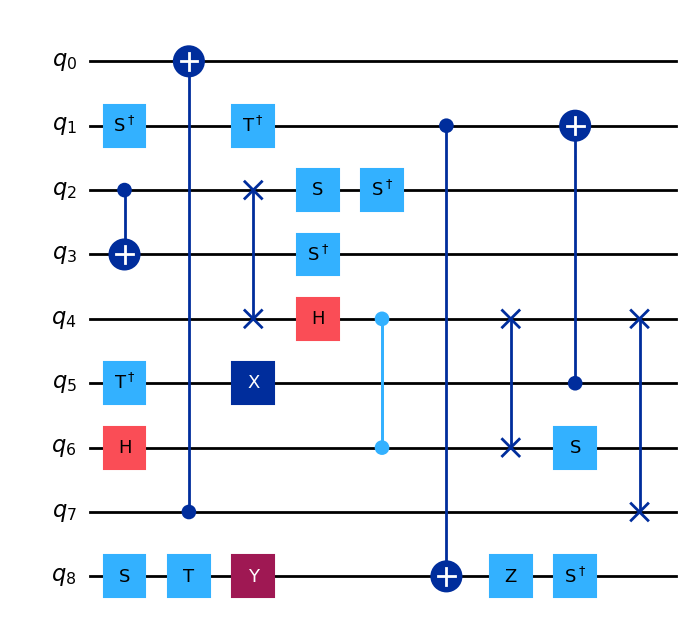

In [1]:
import random
from qiskit import QuantumCircuit
%load_ext autoreload
%autoreload 2

one_qubit_gates = ["h", "s", "sdg", "t", "tdg", "x", "y", "z"]
two_qubit_gates = ["cx","cz","swap"]

def random_circuit_generator(max_qubits, max_depth):
    qubits = random.randint(2, max_qubits)
    depth = random.randint(2, max_depth)
    qc = QuantumCircuit(qubits)

          
    for i in range(depth):
        if random.random() < 0.6:
            q = random.randrange(qubits)
            gate = random.choice(one_qubit_gates)
            getattr(qc, gate)(q)
        else:
            q1, q2 = random.sample(range(qubits), 2)
            gate = random.choice(two_qubit_gates)
            getattr(qc, gate)(q1, q2)

    return qc


qc = random_circuit_generator(60,30)
qc.draw("mpl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

We are on iteration  0 Our new cost is  24.981679490075557 accept= True our best is  24.981679490075557
we try  color_change

We are on iteration  1 Our new cost is  24.99719456960641 accept= True our best is  24.981679490075557
we try  fuse

We are on iteration  2 Our new cost is  19.452017125126847 accept= True our best is  19.452017125126847
we try  fuse

We are on iteration  3 Our new cost is  24.99719456960641 accept= True our best is  19.452017125126847
we try  color_change

We are on iteration  4 Our new cost is  25.086630526308497 accept= True our best is  19.452017125126847
we try  color_change

We are on iteration  5 Our new cost is  25.05213409056502 accept= True our best is  19.452017125126847
we try  remove_id

We are on iteration  6 Our new cost is  25.05213409056502 accept= True our best is  19.452017125126847
we try  pi_commute_Z

We are on iteration  7 Our new cost is  25.143869544

False
0
[]
1
[]
2
[]
3
[]
4
[]
5
[]
6
[]
7
[]
8
[]
9
['color_change']
10
[]
11
['color_change']
12
[]
13
['color_change', 'pi_commute_X']
14
['pi_commute_Z']
15
['color_change']
16
['fuse']
17
['color_change', 'fuse']
18
['color_change', 'remove_id']
19
['color_change', 'fuse']
20
['color_change']
21
['color_change', 'remove_id']
22
['color_change', 'fuse']
23
['color_change']
24
['color_change']
25
[]
26
['color_change', 'fuse']
27
['color_change', 'fuse']
28
['color_change', 'fuse']
29
['color_change', 'pi_commute_X']
30
['color_change', 'pi_commute_Z']
31
['color_change', 'pi_commute_X']
32
[]
33
['color_change', 'pi_commute_X']
34
['pi_commute_Z']
35
['color_change', 'pi_commute_X']
36
[]
37
['color_change', 'pi_commute_X']
38
[]
39
['color_change', 'pi_commute_X']
40
['pi_commute_Z']
41
['color_change']
42
[]
43
['color_change']
44
['color_change', 'fuse']
45
['color_change', 'fuse']
46
['color_change', 'pi_commute_X']
47
['color_change', 'pi_commute_X']
48
['fuse']
49
['color_cha

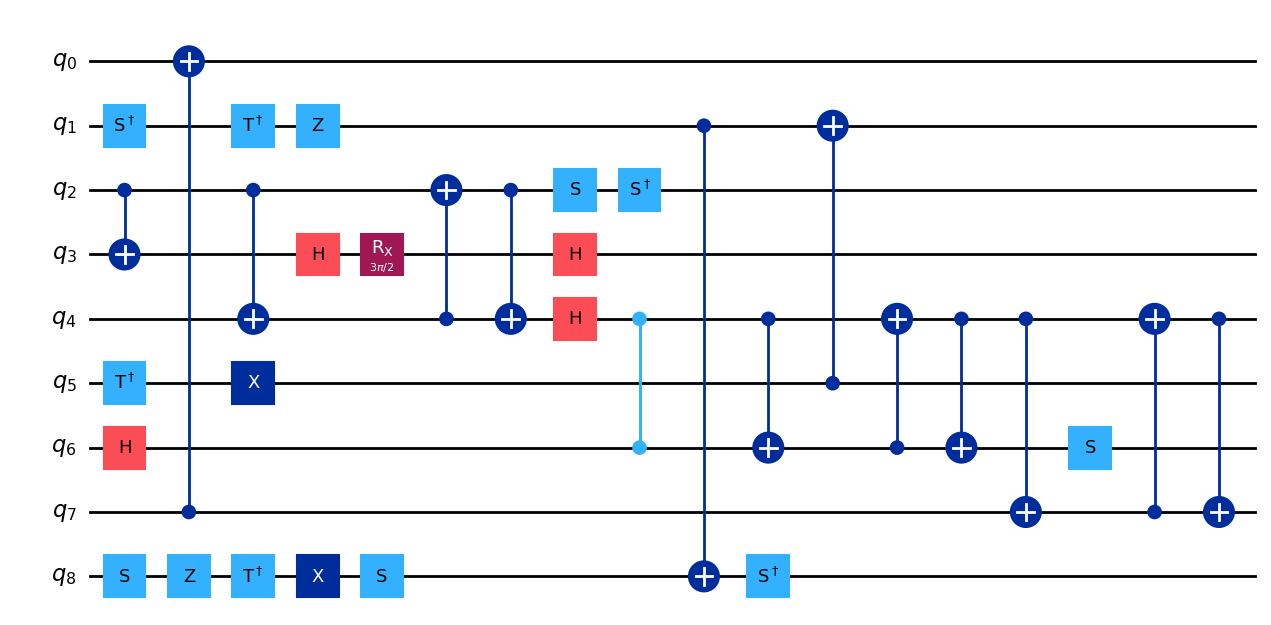

In [42]:
%load_ext autoreload
%autoreload 2

from qiskit.circuit.random import random_circuit
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import simulated_annealing
from quantum_optimiser.multimetric import rewrite

from qiskit import transpile
import pyzx
from IPython.display import display



diagram = integration.qiskit_to_pyzx(qc)

wrapper_function = loss.cost_function_from_circuit(loss.log_weighted_loss)

best_diagram, best_cost, _ = simulated_annealing.simulated_annealing_zx(
                diagram=diagram,
                cost_function=wrapper_function,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=1000,
                max_no_improvement=1000,
            )

pyzx.draw(diagram, labels = "true")
pyzx.draw(best_diagram, labels = "true")
print(new)
for i in range (62):
    print(i)
    print(rewrite.get_applicable_rules(best_diagram,i))
    
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

In [48]:
new=rewrite.try_fuse(best_diagram,6)
pyzx.draw(new,labels="true")

# Evaluating the optimiser
The code below generates 10 random circuits of the same size, and prints out the average decrease in each cost function as well as the average decrease of each metric

In [17]:
import numpy as np

def get_metrics(circuit):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit),
        "gates": metrics.circuit_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit)
    before_L = loss_fn(circuit)
    diagram = integration.qiskit_to_pyzx(circuit)
    wrapper_function = loss.cost_function_from_circuit(loss_fn)

    optimised_diagram, optimised_cost, _ =  simulated_annealing.simulated_annealing_zx(
                diagram=diagram,
                cost_function=wrapper_function,
                get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=500,
                max_no_improvement=50,
            )

    optimised_circuit = integration.pyzx_to_qiskit(optimised_diagram)
    after_m = get_metrics(optimised_circuit)
    after_L = optimised_cost

    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate(n_circuits=10, qubits=50, depth=50):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }

    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}

    

    circuits = [random_circuit_generator(qubits, depth) for i in range(n_circuits)]
    for qc in circuits:
        for name,L in functions.items():
            dL, dm = evaluate_once(qc, L)
            cost_deltas[name].append(dL)
            metric_deltas[name].append(dm)

    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")

    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")

        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():
            print(f"  Avg {k} decrease: {v:.4f}")
        print()


evaluate()


Benchmark over 10 circuits | qubits=50 depth=50

naive
Avg cost decrease: -4.4400
  Avg qubits decrease: 0.0000
  Avg two_qubit decrease: -7.6000
  Avg gates decrease: -11.0000
  Avg depth decrease: -3.7000
  Avg t decrease: 0.1000

informed
Avg cost decrease: -2.8400
  Avg qubits decrease: 0.0000
  Avg two_qubit decrease: -7.6000
  Avg gates decrease: -11.3000
  Avg depth decrease: -4.4000
  Avg t decrease: 0.5000

log_weighted
Avg cost decrease: 2.9807
  Avg qubits decrease: 0.0000
  Avg two_qubit decrease: -7.6000
  Avg gates decrease: -29.1000
  Avg depth decrease: -7.2000
  Avg t decrease: 1.5000

quadratic
Avg cost decrease: -25.8875
  Avg qubits decrease: 0.0000
  Avg two_qubit decrease: -7.6000
  Avg gates decrease: -23.1000
  Avg depth decrease: -4.9000
  Avg t decrease: 1.2000

